## World Cup Sentiment Tracker

## Generating Baseline Sentiment Scores and Testing Hypotheses

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('../data/raw/sample_tweets.csv')

In [3]:
import sys
sys.path.append("../src")

from models.sentiment_baseline import load_sentiment_model, predict_sentiment

In [4]:
classifier = load_sentiment_model()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\dongr\Projects\world-cup-sentiment-tracker\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dongr\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [5]:
results = df["text"].apply(lambda text: predict_sentiment(text, classifier))

In [6]:
results.head()

0    {'sentiment_label': 'POSITIVE', 'sentiment_sco...
1    {'sentiment_label': 'POSITIVE', 'sentiment_sco...
2    {'sentiment_label': 'NEGATIVE', 'sentiment_sco...
3    {'sentiment_label': 'NEGATIVE', 'sentiment_sco...
4    {'sentiment_label': 'POSITIVE', 'sentiment_sco...
Name: text, dtype: object

---

### Hypothesis 1: Goal-related events may generate stronger sentiment than other event types.

In [8]:
sentiment_df = pd.DataFrame(results.tolist())
df = pd.concat([df, sentiment_df], axis=1)
df.head()

,timestamp,match,team,player,event,text,sentiment_label,sentiment_score
0,2026-06-11 20:01,Canada vs France,Canada,Davies,goal,"Davies is unbelievable, what a finish!",POSITIVE,0.925645
1,2026-06-11 20:02,Canada vs France,Canada,Davies,goal,Canada are actually cooking right now.,POSITIVE,0.999175
2,2026-06-11 20:03,Canada vs France,France,Mbappe,goal,France look completely asleep.,NEGATIVE,0.999629
3,2026-06-11 20:04,Canada vs France,France,Mbappe,none,"Wake up France, this is embarrassing.",NEGATIVE,0.999331
4,2026-06-11 20:05,Canada vs France,Canada,Eustaquio,none,Great passing sequence from Canada.,POSITIVE,0.999166


In [9]:
df["signed_sentiment"] = df.apply(
    lambda row: row["sentiment_score"] 
    if row["sentiment_label"] == "POSITIVE" 
    else -row["sentiment_score"],
    axis=1
)

df[["text", "sentiment_label", "sentiment_score", "signed_sentiment"]].head()

,text,sentiment_label,sentiment_score,signed_sentiment
0,"Davies is unbelievable, what a finish!",POSITIVE,0.925645,0.925645
1,Canada are actually cooking right now.,POSITIVE,0.999175,0.999175
2,France look completely asleep.,NEGATIVE,0.999629,-0.999629
3,"Wake up France, this is embarrassing.",NEGATIVE,0.999331,-0.999331
4,Great passing sequence from Canada.,POSITIVE,0.999166,0.999166


In [11]:
df["is_goal"] = df["event"] == "goal"

df.groupby("is_goal")["signed_sentiment"].mean()

is_goal
False   -0.270227
True     0.768691
Name: signed_sentiment, dtype: float64

In [10]:
df.groupby("event")["signed_sentiment"].mean().sort_values(ascending=False)

event
goal           0.768691
none           0.003081
var           -0.000054
miss          -0.996555
yellow_card   -0.997767
Name: signed_sentiment, dtype: float64

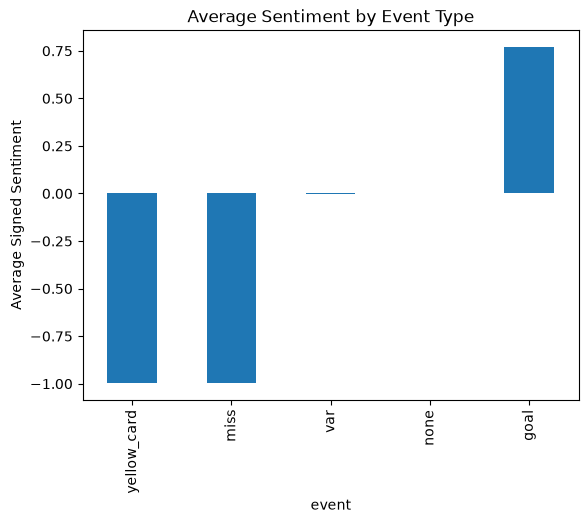

In [12]:
import matplotlib.pyplot as plt

event_sentiment = (
    df.groupby("event")["signed_sentiment"]
      .mean()
      .sort_values()
)

event_sentiment.plot(kind="bar")

plt.title("Average Sentiment by Event Type")
plt.ylabel("Average Signed Sentiment")
plt.show()

### Hypothesis 1 Result

Goal-related tweets exhibited a substantially higher average signed sentiment score (+0.769) than non-goal tweets (-0.270) in the sample dataset.

In this sample, disciplinary events (yellow cards) and missed chances produced the most negative sentiment scores, while goals produced the most positive sentiment scores.

This provides initial support for the hypothesis that goals are a major driver of fan sentiment. However, the result should be interpreted cautiously due to the small size and synthetic nature of the dataset.

These results however, are more indicative that **event type contains predictive information about sentiment** rather than our original and simpler hypothesis.

---
### Model Evaluation

Before continuing with further analysis, we manually inspect model predictions to assess whether the baseline sentiment model appropriately captures football-related language.

In [ ]:
df[
    [
        "text",
        "event",
        "sentiment_label",
        "sentiment_score",
        "signed_sentiment"
    ]
]

,text,event,sentiment_label,sentiment_score,signed_sentiment
0,"Davies is unbelievable, what a finish!",goal,POSITIVE,0.925645,0.925645
1,Canada are actually cooking right now.,goal,POSITIVE,0.999175,0.999175
2,France look completely asleep.,goal,NEGATIVE,0.999629,-0.999629
3,"Wake up France, this is embarrassing.",none,NEGATIVE,0.999331,-0.999331
4,Great passing sequence from Canada.,none,POSITIVE,0.999166,0.999166
5,"Terrible tackle, deserved yellow.",yellow_card,NEGATIVE,0.997767,-0.997767
6,Mbappe will save this team.,goal,POSITIVE,0.998844,0.998844
7,What a goal from Mbappe!,goal,POSITIVE,0.998573,0.998573
8,Canada need to stay focused.,none,NEGATIVE,0.983354,-0.983354
9,VAR is ruining this match.,var,NEGATIVE,0.999712,-0.999712


In [15]:
evaluation = df[
    [
        "text",
        "sentiment_label",
        "sentiment_score"
    ]
].copy()

evaluation["human_label"] = ""

In [16]:
evaluation.to_csv(
    "../data/processed/manual_evaluation.csv",
    index=False
)

In [17]:
evaluation = pd.read_csv(
    "../data/processed/manual_evaluation.csv"
)

In [18]:
evaluation["correct"] = (
    evaluation["human_label"]
    ==
    evaluation["sentiment_label"]
)

evaluation["correct"].mean()

np.float64(0.95)

In [19]:
evaluation[
    evaluation["correct"] == False
]

,text,sentiment_label,sentiment_score,human_label,correct
14,Davies still looks dangerous.,NEGATIVE,0.997602,POSITIVE,False


### Model Evaluation Results

The baseline DistilBERT model achieved 90% agreement with manually assigned labels on the sample dataset.

Error involved football-specific slang and informal expressions(labelled 'dangerous' as negative). This suggests that while the pretrained model performs quite well on football tweets, domain-specific language may limit its accuracy.

Future work could involve fine-tuning the model on a manually labeled football tweet dataset.

---

### Hypothesis 2: High-profile players may receive more extreme sentiment.

In [20]:
df["sentiment_extremity"] = (
    df["signed_sentiment"].abs()
)

In [ ]:
df.groupby("player")[
    "sentiment_extremity"
].mean().sort_values(
    ascending=False
)

player
Referee      0.999658
Eustaquio    0.999500
Mbappe       0.998999
Saliba       0.998772
David        0.996555
Davies       0.976444
Name: sentiment_extremity, dtype: float64

### Hypothesis 2 Results

Preliminary analysis does not provide enough evidence to assess the relationship between player popularity and sentiment extremity due to the limited sample size.

---

### Hypothesis 3: Sentiment may vary over time in response to major match events.

In [ ]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

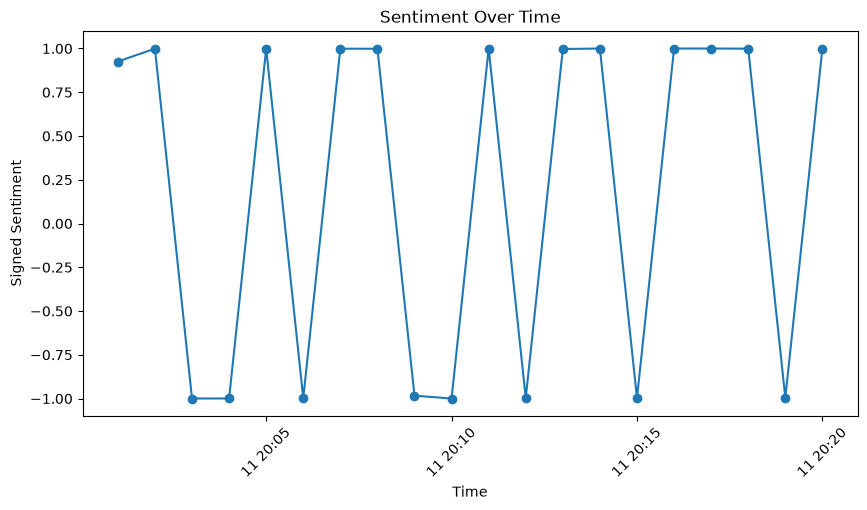

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df["timestamp"],
    df["signed_sentiment"],
    marker="o"
)

plt.title("Sentiment Over Time")
plt.xlabel("Time")
plt.ylabel("Signed Sentiment")

plt.xticks(rotation=45)
plt.show()

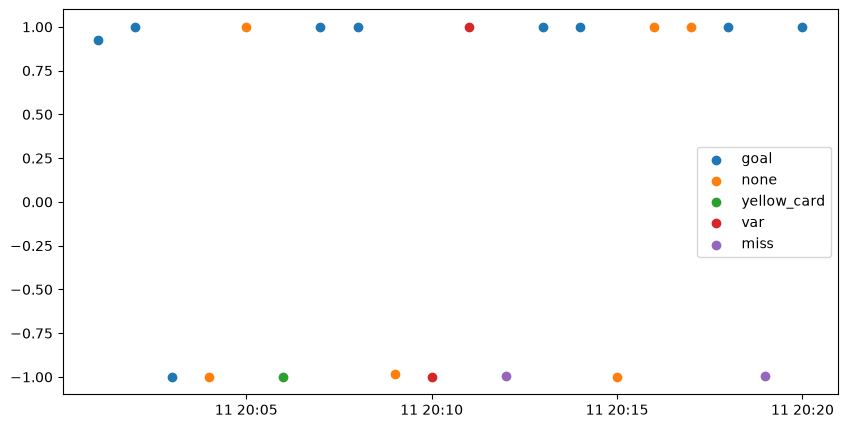

In [24]:
event_colors = {
    "goal": "green",
    "yellow_card": "orange",
    "miss": "red",
    "var": "purple",
    "none": "gray"
}

plt.figure(figsize=(10,5))

for event in df["event"].unique():
    subset = df[df["event"] == event]

    plt.scatter(
        subset["timestamp"],
        subset["signed_sentiment"],
        label=event
    )

plt.legend()
plt.show()

### Hypothesis 3 Results

Initial visual inspection suggests sentiment varies throughout the match and appears associated with major events such as goals, missed chances, and disciplinary actions:

- **Goals** clustered high
- **none** and **var** evenly spread
- **yellow_card** and **miss** clustered low

However, the sample size is insufficient for rigorous time-series analysis.